# Case 3: 3D Full-Body Dyadic (Mirror Game) — reproduction

Two participants perform a mirror game under three visual-coupling conditions —
**back-to-back** (no visual info), **unidirectional** (follower sees leader), and
**face-to-face** (mutual). Recorded in 3-D with ZED stereo cameras (38 keypoints).

We reproduce the Case-3 finding: visual coupling increases whole-body movement
magnitude (acceleration) and leader–follower coordination, from a five-keypoint
subset (head + both wrists + both ankles).

Workflow:
1. **Load & resample** a trial (the ZED stream is variable-rate → uniform 30 Hz).
2. **Choose embedding parameters** `(τ, m)` from AMI/FNN evidence — you commit.
3. **Run the reproduction** across all dyads and trials.
4. **Reproduce the figure.**
5. **Inferential statistics**, and **descriptive movement summaries by condition
   and by role** (did leaders move less when they knew they could not be seen?).
6. **Principal-Movements (PCA) diagnostic.**
7. **MdCRQA** — the two bodies compared as whole five-dimensional systems.


## Configuration

Point these at your Mirror-Game data and the conditions table, and set the run
toggle.

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "" # set to the path of the data directory, e.g. DATA_DIR = "/path/to/data"
from pose_dynamics.case_studies.mirror_game import default_conditions_csv
CONDITIONS_CSV = default_conditions_csv()

RUN_FULL   = True            # False = a few pairs (fast); True = all 18 dyads
SUBSET_PAIRS = [1, 2, 3]     # pairs analyzed when RUN_FULL is False

## 1. Load and resample a trial

`load_and_resample` reads a ZED 3-D export (`timestamp_ns, dt_ms, x0,y0,z0, ...`)
and resamples it from its variable frame rate onto a uniform 30 Hz grid using the
timestamps.

{'source_file': '/Volumes/X9_Pro/Case_Study_3_Mirror_Game/P001_T1_P1_pose_3d.csv', 'n_frames': 1058, 'n_keypoints': 38, 'dims': 3, 'frame_rate': 30.0, 'duration_s': 35.267, 'has_confidence': False, 'missing_fraction': 0.0, 'stages_applied': [], 'meta': {'pair': 1, 'trial': 1, 'person': 1}}


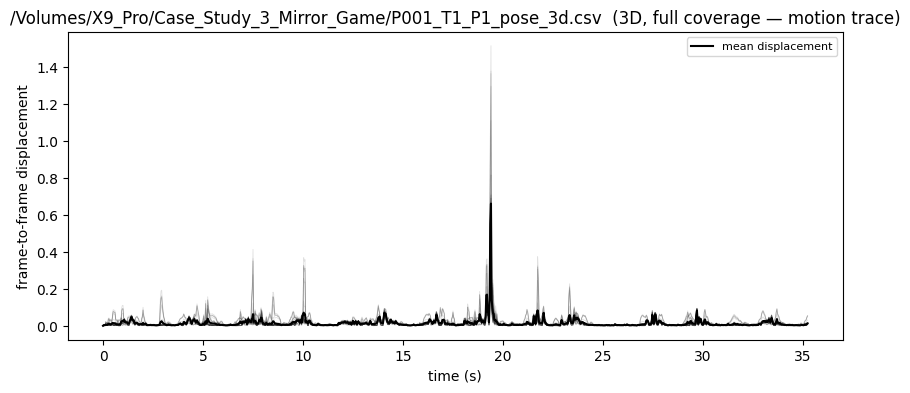

In [2]:
from pose_dynamics.case_studies.mirror_game import load_and_resample, parse_file

sample_file = next(p for p in Path(DATA_DIR).glob("P001_T1_P1_pose_3d.csv") if not p.name.startswith("._"))
seq = load_and_resample(sample_file)
print(seq.summary())
seq.plot_coverage();

## 2. Choosing the embedding parameters (human-in-the-loop)

The CRQA signal is each keypoint's 3-D magnitude time series. We estimate `(τ, m)`
from AMI/FNN across these signals pooled over a few trials, then commit.

Evidence from 30 of 30 signals.

Delay (tau) — relative-shape / plateau heuristic (proposal, confirm from the plot):
  - first prominent local minimum (smoothed) at lag None.
  - plateau onset (diminishing returns) at lag 26.
  - relative 1/e crossing at lag 13.
  - per-signal median suggestion: 29.0.
  => proposed tau = 25 (clamped into grid (10, 25)).

Dimension (m) — FNN diminishing-returns knee at tau=25:
  - knee (elbow of the FNN curve): 3.
  - first dimension with FNN <= 10% (noise floor): 3.
  - per-signal median: 3.0.
  => proposed m = 3.

NOTE: these are proposals, not decisions. Inspect the curves and their spread, then commit a single (tau, m) with evidence.commit(tau, m).


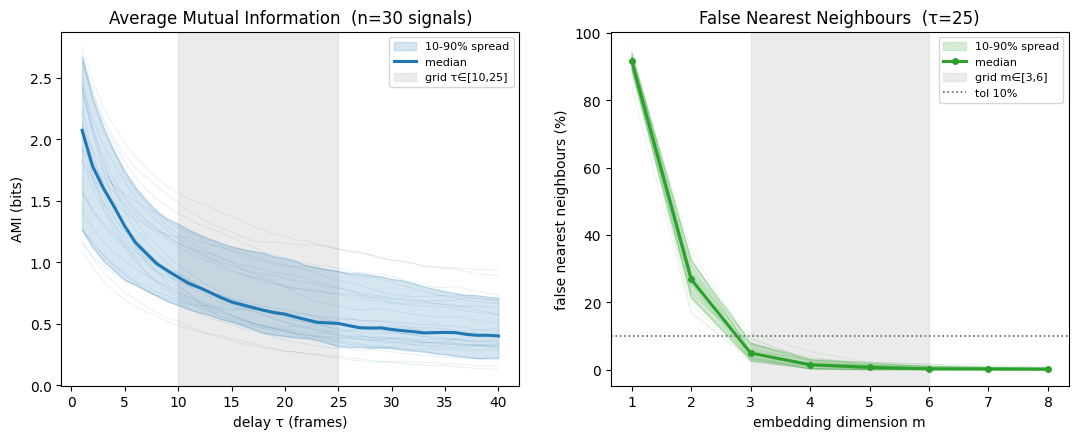

In [3]:
from pose_dynamics.preprocessing import butterworth_filter
from pose_dynamics.features import FeaturePipeline
from pose_dynamics.embedding import (select_embedding, Signal, select_embedding,
                                     plot_embedding_evidence)
from pose_dynamics.case_studies.mirror_game import config as MG  # not `C`: patsy needs that name

# build per-keypoint magnitude signals from a few trials of pair 1
signals = []
for f in sorted(p for p in Path(DATA_DIR).glob("P001_T*_P1_pose_3d.csv") if not p.name.startswith("._"))[:6]:
    s = load_and_resample(f)
    s = butterworth_filter(FeaturePipeline.from_config(
        [{"primitive": "center", "params": {"reference": MG.PELVIS}},
         {"primitive": "select_keypoints", "params": {"indices": MG.SUBSET_INDICES, "names": MG.SUBSET_NAMES}}]
        ).run(s).pose, cutoff_hz=MG.FILTER_CUTOFF, order=MG.FILTER_ORDER)
    for k, name in enumerate(MG.SUBSET_NAMES):
        mag = np.linalg.norm(s.coords[:, k, :], axis=1)
        signals.append(Signal(f"{f.stem}_{name}", mag, group={"keypoint": name}))

evidence = select_embedding(signals, tau_grid=(10, 25), m_grid=(3, 6),
                            ami_max_lag=40, fnn_max_dim=8, subset=40, seed=0)
plot_embedding_evidence(evidence)
print(evidence.justification)

### Commit

Consistent with the paper we commit **τ = 20, m = 4** (the values in the Case-3
config).

In [4]:
params = evidence.commit(tau=20, m=4, notes="Case 3: committed from AMI/FNN")
params.to_dict()

{'tau': 20,
 'm': 4,
 'multivariate': False,
 'chosen_by': 'human_confirmed',
 'proposed_tau': 25,
 'proposed_m': 3,
 'n_signals': 30,
 'notes': 'Case 3: committed from AMI/FNN'}

## 3. Run the reproduction

`run_reproduction` pairs the two participants for each dyad × trial, resamples,
trims to their overlapping window, centres on the pelvis, filters, keeps the
five-keypoint subset, and per keypoint runs **cross-RQA on the magnitude time
series** — averaging across the five keypoints. It also emits displacement,
velocity and acceleration summaries (mean and RMS) **per role** — the conditions
table names the block-1 leader, and roles swap in block 2 — plus the whole-body
**MdCRQA** described in §7.

**Recurrence mode.** These settings target a **fixed 2.5% recurrence rate**, so
%REC is pinned (a convergence check) and the *achieved radius* is the informative
density measure: a smaller radius means the two bodies' states sit closer in phase
space — more coordination.

In [5]:
from pose_dynamics.case_studies.mirror_game import run_reproduction

pairs = None if RUN_FULL else SUBSET_PAIRS
df = run_reproduction(DATA_DIR, CONDITIONS_CSV, pairs=pairs, progress=True)
print(f"{len(df)} dyad-trials; {df['pair'].nunique()} dyads")
print(f"Primary CRQA at fixed radius {df['crossfx_radius'].iloc[0]}; "
      f"%REC is an outcome (mean {df['crossfx_perc_recur'].mean():.2f}%)")
df.groupby("condition", observed=True)[
    ["accel_rms", "crossfx_perc_recur", "crossfx_lmax", "crossfx_mean_line_length",
     "crossfx_trapping_time", "cross_radius", "md_radius", "md_lmax"]].mean()

[1/211] pair 1 trial 1 (b2b)
[2/211] pair 1 trial 2 (uni)
Error in multivariate RQA computation. Check parameters and data.
[3/211] pair 1 trial 3 (f2f)
[4/211] pair 1 trial 4 (uni)
[5/211] pair 1 trial 5 (f2f)
[6/211] pair 1 trial 6 (b2b)
[7/211] pair 1 trial 7 (b2b)
Error in multivariate RQA computation. Check parameters and data.
[8/211] pair 1 trial 9 (f2f)
[9/211] pair 1 trial 10 (uni)
[10/211] pair 1 trial 11 (f2f)
[11/211] pair 1 trial 12 (b2b)
[12/211] pair 2 trial 1 (b2b)
[13/211] pair 2 trial 2 (f2f)
[14/211] pair 2 trial 3 (uni)
[15/211] pair 2 trial 4 (f2f)
[16/211] pair 2 trial 5 (uni)
[17/211] pair 2 trial 9 (uni)
[18/211] pair 2 trial 10 (f2f)
[19/211] pair 2 trial 12 (b2b)
[20/211] pair 3 trial 1 (b2b)
[21/211] pair 3 trial 2 (uni)
[22/211] pair 3 trial 3 (f2f)
[23/211] pair 3 trial 4 (uni)
[24/211] pair 3 trial 5 (f2f)
[25/211] pair 3 trial 6 (b2b)
[26/211] pair 3 trial 7 (b2b)
[27/211] pair 3 trial 8 (uni)
[28/211] pair 3 trial 9 (f2f)
[29/211] pair 3 trial 10 (uni)
[

,accel_rms,crossfx_perc_recur,crossfx_lmax,crossfx_mean_line_length,crossfx_trapping_time,cross_radius,md_radius,md_lmax
condition,,,,,,,,
b2b,5.997489,3.149382,62.028986,6.524639,9.855669,0.305058,0.608894,64.144928
uni,7.090389,3.977591,73.745714,7.264163,11.104441,0.297612,0.589760,82.657143
f2f,7.268744,4.781061,76.828169,8.542912,13.042582,0.288284,0.574136,76.563380


In [6]:
df.to_csv("mirror_case3_results.csv", index=False)

## 4. Reproduce the figure

Group-averaged (mean ± SEM) by visual-coupling condition: acceleration RMS, the
cross-recurrence radius (at 2.5% REC), and the maximum diagonal line length.

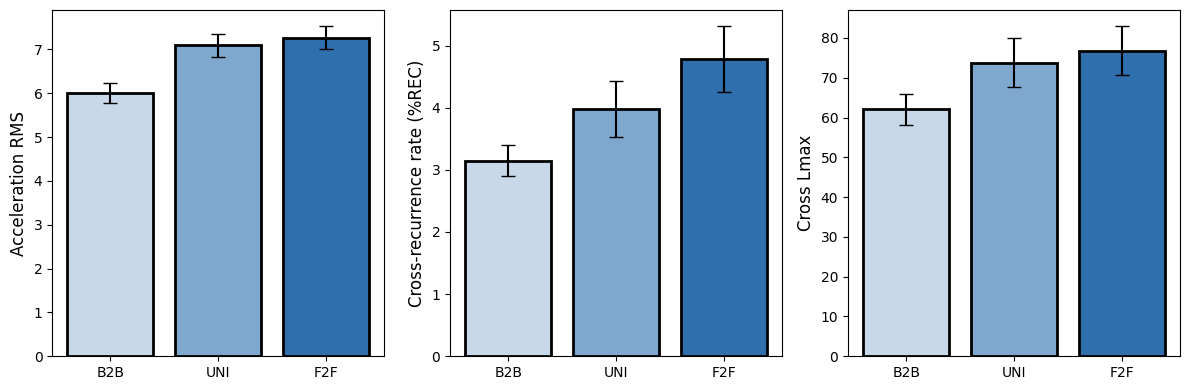

In [7]:
from pose_dynamics.case_studies.mirror_game import plot_case3_figure
plot_case3_figure(df);

## 5. Inferential statistics 

Linear mixed-effects models with a fixed effect of visual-coupling
condition (back-to-back as reference) and a random intercept for pair give the β
coefficients (uni, f2f vs. b2b) the paper's coefficient figure reports.

In [8]:
import statsmodels.formula.api as smf
import pandas as pd
import warnings; warnings.simplefilter("ignore")

from pose_dynamics.case_studies.mirror_game import movement_long, KINEMATIC_FEATURES

# --- kinematics: person-level, Condition + Role + trial order, individual nested in pair
long = movement_long(df)
long["person_id"] = long["pair"].astype(str) + "_" + long["person"].astype(str)

kin_rows = []
for metric in KINEMATIC_FEATURES:
    m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('b2b')) + C(role, Treatment('leader')) + trial",
                    long, groups=long["pair"],
                    vc_formula={"person": "0 + C(person_id)"}).fit()
    for term, label in [("C(condition, Treatment('b2b'))[T.uni]", "uni"),
                        ("C(condition, Treatment('b2b'))[T.f2f]", "f2f")]:
        kin_rows.append({"metric": metric, "vs_b2b": label,
                         "beta": m.params[term], "SE": m.bse[term], "p": m.pvalues[term]})

# --- recurrence: dyad-level, Condition + trial order, random intercept for pair.
# crossfx_* (fixed radius) is primary; cross_* (fixed 2.5% REC) and md_* are secondary.
rqa_metrics = ([c for c in df.columns if c.startswith("crossfx_") and c != "crossfx_radius"]
               + ["cross_perc_recur", "cross_radius", "cross_lmax"]
               + [c for c in df.columns if c.startswith("md_") and c != "md_converged"])
rqa_rows = []
for metric in rqa_metrics:
    m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('b2b')) + trial",
                    df, groups=df["pair"]).fit()
    for term, label in [("C(condition, Treatment('b2b'))[T.uni]", "uni"),
                        ("C(condition, Treatment('b2b'))[T.f2f]", "f2f")]:
        rqa_rows.append({"metric": metric, "vs_b2b": label,
                         "beta": m.params[term], "SE": m.bse[term], "p": m.pvalues[term]})

coefs = pd.DataFrame(kin_rows + rqa_rows)
coefs.round(4)

,metric,vs_b2b,beta,SE,p
0,disp_mean,uni,0.0022,0.0005,0.0000
1,disp_mean,f2f,0.0030,0.0005,0.0000
2,disp_rms,uni,0.0033,0.0006,0.0000
3,disp_rms,f2f,0.0043,0.0006,0.0000
4,vel_mean,uni,0.0641,0.0151,0.0000
...,...,...,...,...,...
73,md_complexity,f2f,0.0165,0.0670,0.8060
74,md_trend_lower_diag,uni,0.2672,1.0718,0.8032
75,md_trend_lower_diag,f2f,-0.7595,1.0680,0.4770
76,md_trend_upper_diag,uni,-1.2250,0.8477,0.1484


## 5b. How much did participants actually move? (descriptives by condition and role)

The models above report whether condition *coefficients* are reliable; they do not
say how much people moved. Two questions motivate the descriptives below:

1. Did participants move as much when instructed to follow someone they **could not
   see at all** (back-to-back)?
2. Did the **leader** move as much when they knew the follower could not see them?

The conditions table names the block-1 leader and roles swap in block 2, so each
dyad-trial is split into a leader and a follower row. `movement_summary` reports
mean, SD and n for displacement, velocity and acceleration (mean and RMS) at both
the condition level and the condition × role level.

In [9]:
from pose_dynamics.case_studies.mirror_game import (movement_summary, movement_long,
                                                   KINEMATIC_FEATURES)

# condition-level descriptives (both participants pooled)
cond_desc = movement_summary(df, by_role=False)
print("Movement by condition (mean, SD, n):")
display(cond_desc.round(4))

# condition x role descriptives
role_desc = movement_summary(df, by_role=True)
print("\nMovement by condition x role (mean, SD, n):")
display(role_desc.round(4))

Movement by condition (mean, SD, n):


disp_mean               disp_rms               vel_mean          \
               mean     std count     mean     std count     mean     std   
condition                                                                   
b2b          0.0161  0.0052    69   0.0218  0.0064    69   0.4788  0.1530   
uni          0.0185  0.0056    70   0.0253  0.0070    70   0.5480  0.1644   
f2f          0.0193  0.0060    71   0.0262  0.0071    71   0.5711  0.1784   

                vel_rms               accel_mean               accel_rms  \
          count    mean     std count       mean     std count      mean   
condition                                                                  
b2b          69  0.6440  0.1878    69     4.3014  1.5428    69    5.9975   
uni          70  0.7466  0.2075    70     5.0365  1.7342    70    7.0904   
f2f          71  0.7752  0.2090    71     5.1623  1.7715    71    7.2687   

                         
              std count  
condition                
b2b        1.9201    69  
uni        2.2725    70  
f2f        2.1399    71


Movement by condition x role (mean, SD, n):


disp_mean               disp_rms               vel_mean  \
                        mean     std count     mean     std count     mean   
condition role                                                               
b2b       follower    0.0145  0.0057    69   0.0197  0.0072    69   0.4300   
          leader      0.0178  0.0059    69   0.0238  0.0073    69   0.5276   
uni       follower    0.0182  0.0055    70   0.0248  0.0068    70   0.5390   
          leader      0.0188  0.0060    70   0.0258  0.0077    70   0.5571   
f2f       follower    0.0184  0.0055    71   0.0253  0.0067    71   0.5443   
          leader      0.0202  0.0068    71   0.0272  0.0080    71   0.5980   

                                 vel_rms               accel_mean          \
                       std count    mean     std count       mean     std   
condition role                                                              
b2b       follower  0.1684    69  0.5835  0.2119    69     3.8371  1.6648   
          leader    0.1760    69  0.7045  0.2156    69     4.7657  1.8506   
uni       follower  0.1619    70  0.7323  0.2011    70     4.9046  1.6789   
          leader    0.1776    70  0.7610  0.2272    70     5.1684  1.9067   
f2f       follower  0.1643    71  0.7473  0.1969    71     4.9522  1.6434   
          leader    0.2022    71  0.8031  0.2349    71     5.3724  2.0191   

                         accel_rms                
                   count      mean     std count  
condition role                                    
b2b       follower    69    5.3971  2.1596    69  
          leader      69    6.5979  2.2917    69  
uni       follower    70    6.8479  2.1953    70  
          leader      70    7.3328  2.5512    70  
f2f       follower    71    7.0360  2.0411    71  
          leader      71    7.5015  2.4370    71

In [10]:
# Condition x Role model: does the leader's movement depend on being seen?
long = movement_long(df)
long["person_id"] = long["pair"].astype(str) + "_" + long["person"].astype(str)

role_rows = []
for metric in KINEMATIC_FEATURES:
    m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('b2b')) * C(role, Treatment('leader'))",
                    long, groups=long["pair"]).fit()
    for term in m.params.index:
        if term in ("Intercept", "Group Var"):
            continue
        role_rows.append({"metric": metric, "term": term,
                          "beta": m.params[term], "SE": m.bse[term], "p": m.pvalues[term]})
role_models = pd.DataFrame(role_rows)
role_models["term"] = (role_models["term"]
                       .str.replace("C(condition, Treatment('b2b'))", "cond", regex=False)
                       .str.replace("C(role, Treatment('leader'))", "role", regex=False))
display(role_models.round(4))

# percentage change relative to the back-to-back baseline, within role
means = long.groupby(["role", "condition"], observed=True)[KINEMATIC_FEATURES].mean()
pct = means.groupby("role").apply(lambda g: (g / g.xs("b2b", level="condition").iloc[0] - 1) * 100)
print("\n% change relative to back-to-back, within role:")
display(pct.round(1))

,metric,term,beta,SE,p
0,disp_mean,cond[T.uni],0.0008,0.0007,0.2626
1,disp_mean,cond[T.f2f],0.0023,0.0007,0.0022
2,disp_mean,role[T.follower],-0.0033,0.0007,0.0000
3,disp_mean,cond[T.uni]:role[T.follower],0.0027,0.0010,0.0106
4,disp_mean,cond[T.f2f]:role[T.follower],0.0015,0.0010,0.1534
5,disp_rms,cond[T.uni],0.0017,0.0009,0.0599
6,disp_rms,cond[T.f2f],0.0032,0.0009,0.0005
7,disp_rms,role[T.follower],-0.0041,0.0009,0.0000
8,disp_rms,cond[T.uni]:role[T.follower],0.0031,0.0013,0.0171
9,disp_rms,cond[T.f2f]:role[T.follower],0.0022,0.0013,0.0870



% change relative to back-to-back, within role:


disp_mean  disp_rms  vel_mean  vel_rms  \
role     role     condition                                           
follower follower b2b              0.0       0.0       0.0      0.0   
                  uni             25.4      25.5      25.3     25.5   
                  f2f             26.6      28.1      26.6     28.1   
leader   leader   b2b              0.0       0.0       0.0      0.0   
                  uni              5.7       8.1       5.6      8.0   
                  f2f             13.3      14.0      13.3     14.0   

                             accel_mean  accel_rms  
role     role     condition                         
follower follower b2b               0.0        0.0  
                  uni              27.8       26.9  
                  f2f              29.1       30.4  
leader   leader   b2b               0.0        0.0  
                  uni               8.5       11.1  
                  f2f              12.7       13.7

## 6. Principal-Movements (PCA) diagnostic

A global PCA on the centred, Procrustes-aligned, filtered 38-keypoint 3-D poses
decomposes whole-body motion into **Principal Movements (PMs)**. This is used only
as a data-quality / structure diagnostic — the recurrence analyses use the
five-keypoint subset, not PC scores. The paper reports the first ~14 PMs capturing
~94% of postural variance.

  skipped 1 unusable trial(s): P018_T12_P2_pose_3d.csv (0 frames)
17 PMs reach 96% variance; 14 PMs = 94.1%


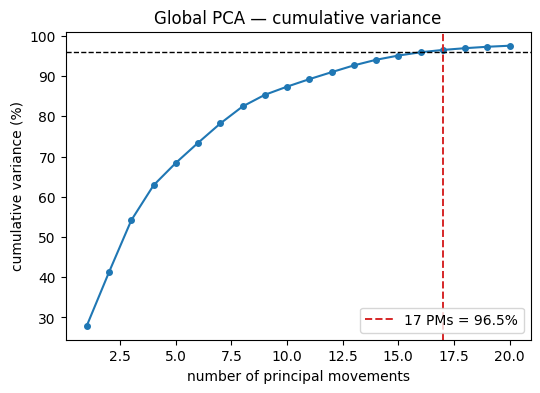

In [11]:
from pose_dynamics.case_studies.mirror_game import run_pca_diagnostic, plot_variance, plot_principal_movements

# build the file list for the PCA fit (a subset of pairs gives a stable decomposition)
all_files = [str(p) for p in Path(DATA_DIR).glob("P*_T*_P*_pose_3d.csv") if not p.name.startswith("._")]
pca_files = all_files if RUN_FULL else [f for f in all_files if any(f"P00{p}_" in f for p in (1, 2, 3, 4))]
model, n_kp = run_pca_diagnostic(pca_files, n_components=20, progress=False)
print(f"{model.n_components_for(0.96)} PMs reach 96% variance; "
      f"14 PMs = {model.cumulative_variance()[13]*100:.1f}%")
plot_variance(model);

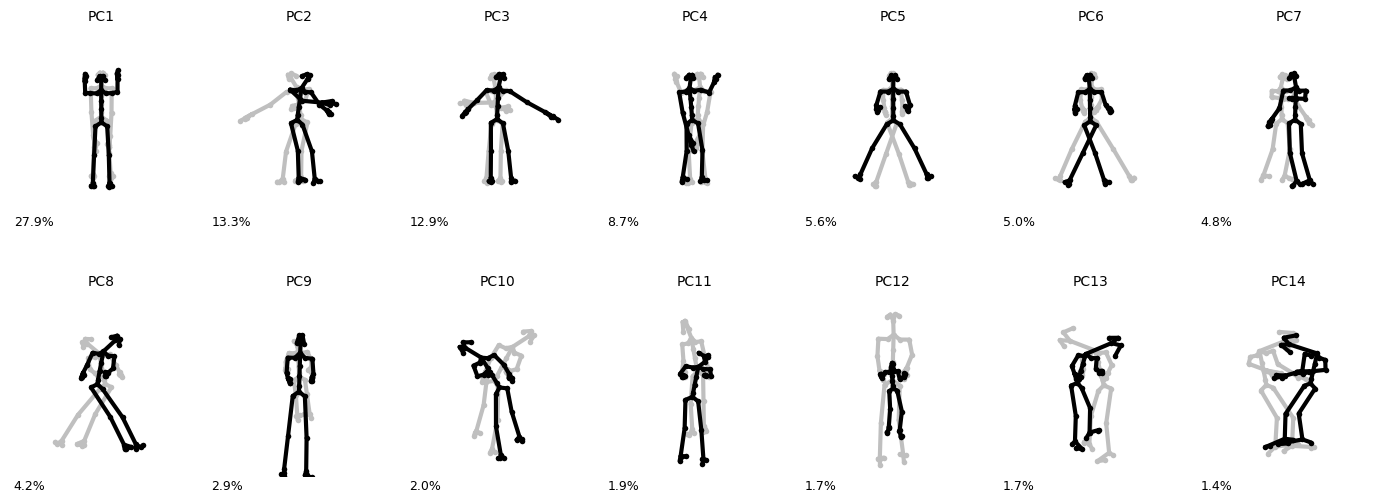

In [12]:
plot_principal_movements(model, n_kp, n_pms=14);

## 7. MdCRQA — the two bodies as whole multivariate systems

The CRQA above is run **per keypoint** and then averaged, so each of the five
keypoints is compared in isolation and the whole-body configuration is never
represented. **MdCRQA** instead treats each participant's five keypoint-magnitude
signals as a single five-dimensional system and asks when the follower's whole-body
state matches a state the leader previously occupied.

Construction (computed inside `run_reproduction`, via `md_cross_rqa_row`):

1. Stack the five keypoint magnitude series into a `(T, 5)` matrix per person.
2. **Z-score each dimension** so no keypoint dominates the distance metric.
3. **Delay-embed** the multivariate signal with the shared `(τ = 20, m = 4)`,
   giving a `(T − (m−1)τ, 20)` collective state trajectory per person.
4. Cross-recurrence between the two trajectories at a fixed 2.5% recurrence rate.

Because the recurrence rate is pinned, the **achieved radius** is the density
measure and the line-based metrics (`md_perc_determ`, `md_mean_line`, `md_lmax`,
`md_trapping_time`) carry the temporal structure.

Note the contrast with **MdRQA**, which would embed *one* person's five-dimensional
vector and quantify when that single body returns to its own previously visited
collective states — internal whole-body organization, rather than coordination
between two bodies.

In [13]:
MD_METRICS = ["md_radius", "md_perc_determ", "md_laminarity", "md_mean_line",
              "md_lmax", "md_entropy", "md_trapping_time"]

print("MdCRQA descriptives by condition (mean, SD, n):")
display(df.groupby("condition", observed=True)[MD_METRICS]
          .agg(["mean", "std", "count"]).round(4))

print("\nMdCRQA condition effects (b2b reference):")
display(coefs[coefs["metric"].str.startswith("md_")].round(4))

# Do MdCRQA and the keypoint-averaged CRQA agree, or add information?
print("\nCorrelation between MdCRQA and keypoint-averaged CRQA:")
display(df[["cross_radius", "cross_lmax", "md_radius", "md_lmax",
            "md_perc_determ"]].corr().round(3))

MdCRQA descriptives by condition (mean, SD, n):


md_radius               md_perc_determ               md_laminarity  \
               mean     std count           mean     std count          mean   
condition                                                                      
b2b          0.6089  0.0656    69        98.7126  0.8142    69        0.9937   
uni          0.5898  0.0813    70        98.5739  0.9864    70        0.9934   
f2f          0.5741  0.0929    71        98.5257  1.1463    71        0.9931   

                        md_mean_line  ...        md_lmax                 \
              std count         mean  ... count     mean      std count   
condition                             ...                                 
b2b        0.0043    69       8.0807  ...    69  64.1449  25.6069    69   
uni        0.0046    70       7.9400  ...    70  82.6571  44.3768    70   
f2f        0.0059    71       8.2300  ...    71  76.5634  35.2034    71   

          md_entropy               md_trapping_time                
                mean     std count             mean     std count  
condition                                                          
b2b           3.8759  0.5478    69          11.4263  5.6274    69  
uni           3.8423  0.5515    70          11.2157  4.5314    70  
f2f           3.8538  0.6414    71          11.8435  6.6576    71  

[3 rows x 21 columns]


MdCRQA condition effects (b2b reference):


,metric,vs_b2b,beta,SE,p
46,md_perc_recur,uni,0.0090,0.0045,0.0462
47,md_perc_recur,f2f,0.0078,0.0045,0.0862
48,md_radius,uni,-0.0217,0.0091,0.0167
49,md_radius,f2f,-0.0354,0.0090,0.0001
50,md_mean_line,uni,-0.0481,0.4798,0.9202
51,md_mean_line,f2f,0.1869,0.4779,0.6957
52,md_lmax,uni,18.7423,5.6072,0.0008
53,md_lmax,f2f,12.4931,5.5863,0.0253
54,md_perc_determ,uni,-0.1253,0.1297,0.3338
55,md_perc_determ,f2f,-0.1849,0.1292,0.1523



Correlation between MdCRQA and keypoint-averaged CRQA:


,cross_radius,cross_lmax,md_radius,md_lmax,md_perc_determ
cross_radius,1.000,-0.685,0.878,-0.434,-0.605
cross_lmax,-0.685,1.000,-0.561,0.488,0.675
md_radius,0.878,-0.561,1.000,-0.451,-0.581
md_lmax,-0.434,0.488,-0.451,1.000,0.536
md_perc_determ,-0.605,0.675,-0.581,0.536,1.000


### 7b. MdCRQA at a *fixed radius* — %REC as an outcome

Under the fixed-2.5%-REC mode above, the recurrence rate is pinned by construction,
so it cannot test whether visual coupling changes how *often* the two bodies occupy
similar states — that question has to be read off the achieved radius instead.

Fixing the **radius** inverts this: the threshold is held constant across trials and
**%REC becomes a result**. The primary radius (`MD_RADIUS = 0.59`) is the grand mean
radius the fixed-REC solution converged on, so both modes are centred on the same
recurrence density and differ only in which quantity is free to vary.

A fixed-radius result depends on the radius chosen, so the sweep below refits the
condition effects across a grid of radii. A conclusion worth reporting is one whose
*direction and relative ordering* hold across the grid, not one that appears at a
single threshold.

In [14]:
MDFX = [c for c in df.columns if c.startswith("mdfx_") and c != "mdfx_radius"]

print(f"Fixed radius = {df['mdfx_radius'].iloc[0]}; %REC is now free to vary "
      f"(range {df['mdfx_perc_recur'].min():.2f}-{df['mdfx_perc_recur'].max():.2f}%)")
print("\nFixed-radius MdCRQA descriptives by condition (mean, SD):")
display(df.groupby("condition", observed=True)[
    ["mdfx_perc_recur", "mdfx_perc_determ", "mdfx_mean_line_length",
     "mdfx_std_line_length", "mdfx_maxl_found", "mdfx_trapping_time", "mdfx_entropy"]]
    .agg(["mean", "std"]).round(4))

fx_rows = []
for metric in MDFX:
    m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('b2b')) + trial",
                    df, groups=df["pair"]).fit()
    for term, label in [("C(condition, Treatment('b2b'))[T.uni]", "uni"),
                        ("C(condition, Treatment('b2b'))[T.f2f]", "f2f")]:
        fx_rows.append({"metric": metric, "vs_b2b": label, "beta": m.params[term],
                        "SE": m.bse[term], "p": m.pvalues[term]})
fx_coefs = pd.DataFrame(fx_rows)
print("\nFixed-radius MdCRQA condition effects (b2b reference):")
display(fx_coefs.round(4))

Fixed radius = 0.59; %REC is now free to vary (range 0.13-19.46%)

Fixed-radius MdCRQA descriptives by condition (mean, SD):


mdfx_perc_recur         mdfx_perc_determ          \
                     mean     std             mean     std   
condition                                                    
b2b                2.5357  2.9764          98.0205  1.8060   
uni                3.3358  3.6467          97.9432  2.4091   
f2f                4.0190  4.3519          97.8647  2.5470   

          mdfx_mean_line_length         mdfx_std_line_length           \
                           mean     std                 mean      std   
condition                                                               
b2b                      8.3797  5.3444               8.5507   8.1826   
uni                      8.9142  5.5016              10.4905   8.9934   
f2f                      9.9005  7.6137              11.8282  13.0024   

          mdfx_maxl_found          mdfx_trapping_time          mdfx_entropy  \
                     mean      std               mean      std         mean   
condition                                                                     
b2b               60.6667  42.5885            12.1323   8.5907       3.7421   
uni               95.0571  75.9000            12.5957   7.9586       3.8040   
f2f               91.6901  79.5312            14.4708  12.6054       3.8814   

                   
              std  
condition          
b2b        0.8525  
uni        0.9006  
f2f        1.0078


Fixed-radius MdCRQA condition effects (b2b reference):


,metric,vs_b2b,beta,SE,p
0,mdfx_perc_recur,uni,0.9285,0.4243,0.0286
1,mdfx_perc_recur,f2f,1.5183,0.4227,0.0003
2,mdfx_perc_determ,uni,-0.0572,0.2945,0.8459
3,mdfx_perc_determ,f2f,-0.1611,0.2934,0.5829
4,mdfx_laminarity,uni,0.0005,0.0015,0.7292
5,mdfx_laminarity,f2f,-0.0005,0.0015,0.7336
6,mdfx_mean_line_length,uni,0.7150,0.7799,0.3593
7,mdfx_mean_line_length,f2f,1.5897,0.7769,0.0407
8,mdfx_std_line_length,uni,2.1915,1.3329,0.1002
9,mdfx_std_line_length,f2f,3.3759,1.3278,0.0110


The MdCRQA counterpart of the Case-3 figure: %REC, Lmax, and trapping time by
visual-coupling condition (mean ± SEM), at the fixed radius.

In [ ]:
from pose_dynamics.case_studies.mirror_game import plot_md_figure
plot_md_figure(df);

In [15]:
from pose_dynamics.case_studies.mirror_game import run_md_radius_sweep

sweep = run_md_radius_sweep(DATA_DIR, CONDITIONS_CSV, pairs=pairs, progress=False)
sweep.to_csv("mirror_case3_md_radius_sweep.csv", index=False)
print(f"{len(sweep)} rows = {sweep['radius'].nunique()} radii x "
      f"{sweep.groupby('radius').size().iloc[0]} dyad-trials")

print("\n%REC achieved at each radius (mean by condition):")
display(sweep.pivot_table(index="radius", columns="condition",
                          values="perc_recur", observed=True).round(3))

# refit the condition effects at every radius: does the conclusion hold across the grid?
sweep_rows = []
for r, grp in sweep.groupby("radius"):
    for metric in ["perc_recur", "perc_determ", "maxl_found", "mean_line_length",
                   "trapping_time", "entropy"]:
        m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('b2b')) + trial",
                        grp, groups=grp["pair"]).fit()
        for term, label in [("C(condition, Treatment('b2b'))[T.uni]", "uni"),
                            ("C(condition, Treatment('b2b'))[T.f2f]", "f2f")]:
            sweep_rows.append({"radius": r, "metric": metric, "vs_b2b": label,
                               "beta": m.params[term], "p": m.pvalues[term]})
sweep_coefs = pd.DataFrame(sweep_rows)

print("\nCondition effects across the radius grid (beta; * = p < .05):")
tab = sweep_coefs.assign(
    cell=lambda d: d.beta.round(3).astype(str) + np.where(d.p < .05, "*", "")
).pivot_table(index=["metric", "vs_b2b"], columns="radius", values="cell",
              aggfunc="first", observed=True)
display(tab)

1050 rows = 5 radii x 210 dyad-trials

%REC achieved at each radius (mean by condition):


condition,b2b,uni,f2f
radius,,,
0.50,0.734,1.221,1.652
0.55,1.524,2.190,2.748
0.59,2.536,3.336,4.019
0.61,3.216,4.071,4.818
0.65,5.002,5.944,6.809



Condition effects across the radius grid (beta; * = p < .05):


radius                      0.50     0.55     0.59     0.61     0.65
metric           vs_b2b                                             
entropy          f2f      0.255*    0.194    0.147    0.133    0.108
                 uni       0.215    0.162    0.088    0.068    0.033
maxl_found       f2f     24.979*  29.773*  31.529*  33.871*  39.413*
                 uni     25.087*  30.768*  35.897*  38.666*  44.955*
mean_line_length f2f      1.635*   1.532*    1.59*   1.648*   1.786*
                 uni       0.718     0.76    0.715    0.649    0.549
perc_determ      f2f       0.099   -0.185   -0.161   -0.088   -0.081
                 uni       0.076    -0.07   -0.057   -0.033   -0.075
perc_recur       f2f      0.936*   1.251*   1.518*   1.641*   1.853*
                 uni      0.548*   0.762*   0.929*     1.0*    1.12*
trapping_time    f2f      2.146*      1.8    1.699    1.733    1.763
                 uni       0.498    0.367     0.21    0.089     -0.3

### 7c. Per-keypoint CRQA at fixed radii — kept per landmark

The same fixed-radius logic applied to the **per-keypoint** CRQA, and here the five
keypoints are *not* averaged, so condition effects can be read for each landmark.

The grid runs 0.15–0.40, spanning the radii the fixed-2.5%-REC solution actually
converged on (0.146–0.409). Note that the *mean* of those solved radii (0.297) is
not the density-matched anchor: per-keypoint radii are heterogeneous and %REC rises
steeply with radius, so one mid-range radius delivers far more than 2.5% recurrence.
**0.15** is the radius that reproduces roughly the 2.5% density and is used as the
primary; the rest of the grid is the sensitivity check.

In [16]:
from pose_dynamics.case_studies.mirror_game import run_crqa_radius_sweep

kp = run_crqa_radius_sweep(DATA_DIR, CONDITIONS_CSV, pairs=pairs, progress=False)
kp.to_csv("mirror_case3_crqa_keypoint_sweep.csv", index=False)
print(f"{len(kp)} rows = {kp['radius'].nunique()} radii x {kp['keypoint'].nunique()} keypoints "
      f"x {len(kp) // (kp['radius'].nunique() * kp['keypoint'].nunique())} dyad-trials")

print("\n%REC delivered at each radius (which radius is density-matched to 2.5%?):")
display(kp.pivot_table(index="radius", columns="keypoint", values="perc_recur",
                       observed=True).round(2))

# (a) pooled across keypoints, across the grid
pool_rows = []
for r, g in kp.groupby("radius"):
    agg = g.groupby(["pair", "trial", "condition"], observed=True)[
        ["perc_recur", "perc_determ", "maxl_found", "mean_line_length",
         "std_line_length", "trapping_time"]].mean().reset_index()
    for metric in ["perc_recur", "perc_determ", "maxl_found", "mean_line_length",
                   "std_line_length", "trapping_time"]:
        m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('b2b')) + trial",
                        agg, groups=agg["pair"]).fit()
        for term, label in [("C(condition, Treatment('b2b'))[T.uni]", "uni"),
                            ("C(condition, Treatment('b2b'))[T.f2f]", "f2f")]:
            pool_rows.append({"radius": r, "metric": metric, "vs": label,
                              "beta": m.params[term], "p": m.pvalues[term]})
pool = pd.DataFrame(pool_rows)
pool["cell"] = pool.beta.round(2).astype(str) + np.where(pool.p < .05, "*", "")
print("\nPooled across keypoints, condition effects across the radius grid (* = p<.05):")
display(pool.pivot_table(index=["metric", "vs"], columns="radius", values="cell",
                         aggfunc="first", observed=True))

# (b) per keypoint, at the primary radius
kp_rows = []
for (name, r), g in kp[kp.radius == 0.15].groupby(["keypoint", "radius"], observed=True):
    for metric in ["perc_recur", "perc_determ", "maxl_found", "mean_line_length",
                   "std_line_length", "trapping_time"]:
        m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('b2b')) + trial",
                        g, groups=g["pair"]).fit()
        for term, label in [("C(condition, Treatment('b2b'))[T.uni]", "uni"),
                            ("C(condition, Treatment('b2b'))[T.f2f]", "f2f")]:
            kp_rows.append({"keypoint": name, "metric": metric, "vs": label,
                            "beta": m.params[term], "SE": m.bse[term], "p": m.pvalues[term]})
per_kp = pd.DataFrame(kp_rows)
per_kp["cell"] = per_kp.beta.round(2).astype(str) + np.where(per_kp.p < .05, "*", "")
print("\nPer keypoint at radius = 0.15 (* = p<.05):")
display(per_kp.pivot_table(index=["metric", "vs"], columns="keypoint", values="cell",
                           aggfunc="first", observed=True))

6300 rows = 6 radii x 5 keypoints x 210 dyad-trials

%REC delivered at each radius (which radius is density-matched to 2.5%?):


keypoint,head,l_ankle,l_wrist,r_ankle,r_wrist
radius,,,,,
0.15,0.27,0.89,0.40,1.06,0.43
0.20,0.75,1.92,0.99,2.17,1.00
0.25,1.58,3.33,1.89,3.71,1.90
0.30,2.82,5.12,3.14,5.65,3.15
0.35,4.52,7.31,4.77,7.97,4.77
0.40,6.69,9.87,6.79,10.65,6.77



Pooled across keypoints, condition effects across the radius grid (* = p<.05):


radius                 0.15   0.20   0.25    0.30    0.35    0.40
metric           vs                                              
maxl_found       f2f  9.11*  11.7*  12.6*  15.36*  20.14*  26.19*
                 uni  5.65*  9.95*  11.1*  13.32*  18.05*  23.87*
mean_line_length f2f  0.98*  1.37*   1.7*   2.09*   2.46*   2.71*
                 uni   0.52   0.63   0.83    0.94    1.01    1.02
perc_determ      f2f  -0.77  -0.95  -0.84   -0.63   -0.45   -0.33
                 uni  -1.19  -0.93  -0.88   -0.65   -0.51   -0.36
perc_recur       f2f  0.53*  0.95*  1.35*   1.68*   1.91*   2.04*
                 uni  0.33*  0.59*  0.82*   0.99*   1.11*   1.17*
std_line_length  f2f  1.44*  2.04*  2.45*   2.96*    3.4*   3.73*
                 uni    0.9   1.14   1.33     1.5    1.68    1.73
trapping_time    f2f  1.32*  1.87*  2.46*   3.17*   3.78*   4.24*
                 uni   0.49   0.49   0.66    0.75    0.76    0.69


Per keypoint at radius = 0.15 (* = p<.05):


keypoint                head l_ankle l_wrist r_ankle r_wrist
metric           vs                                         
maxl_found       f2f  -8.61*  15.83*   6.61*  21.97*   9.57*
                 uni  -8.86*  12.74*    3.12   12.88    7.85
mean_line_length f2f  -0.77*   2.01*   0.82*   2.02*     0.8
                 uni  -0.67*     1.0    0.39    0.74   1.09*
perc_determ      f2f  -5.33*   -2.42    2.23    0.27    1.38
                 uni   -6.9*   -1.88   -0.04    1.32     1.5
perc_recur       f2f   -0.2*   0.93*   0.31*    1.2*   0.39*
                 uni  -0.19*   0.66*     0.2    0.66   0.29*
std_line_length  f2f  -1.02*   2.79*    1.1*    3.0*    1.28
                 uni  -0.95*     1.8    0.54    1.38   1.67*
trapping_time    f2f  -1.03*    3.4*   1.11*   2.86*    0.22
                 uni  -0.81*    1.37    0.19     0.7    0.96

### 7d. Surrogate-pair baseline — is the coordination real?

Back-to-back is an *empirical* baseline: partners still perform the same task, in
the same room, at the same time. It cannot separate genuine interpersonal coupling
from shared task structure — and because participants demonstrably **move more**
under visual coupling (§5b), a fixed-radius recurrence increase could reflect
changed movement statistics rather than coordination.

A **surrogate-pair** baseline separates them. Each trial's leader is re-paired with
a *different dyad's* follower **from the same condition**: two people who never
interacted, but performed the same task under the same instruction. Whatever
recurrence survives is attributable to shared task and movement statistics.

The decisive quantity is the **condition × kind interaction**. If surrogates show
the same condition gradient as real dyads, the effect is about how people move, not
how they coordinate. This matters most for the **ankles**, where the largest effects
sat in §7c and where standing postural sway could couple two people incidentally.

In [17]:
from pose_dynamics.case_studies.mirror_game import run_surrogate_analysis

sur = run_surrogate_analysis(DATA_DIR, CONDITIONS_CSV, pairs=pairs,
                             radius=0.30, n_surrogates=5, seed=0, progress=False)
sur.to_csv("mirror_case3_surrogate.csv", index=False)
print(f"{len(sur)} rows | real: {(sur.kind=='real').sum()}, surrogate: {(sur.kind=='surrogate').sum()}")

METRICS = ["perc_recur", "maxl_found", "mean_line_length", "trapping_time"]

print("\nReal vs surrogate, pooled across keypoints (mean):")
display(sur.groupby(["kind", "condition"], observed=True)[METRICS].mean().round(3))

# trial-level means, then the decisive condition x kind interaction
agg = sur.groupby(["pair", "trial", "condition", "kind"], observed=True)[METRICS].mean().reset_index()
inter = []
for metric in METRICS:
    m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('b2b')) * C(kind, Treatment('surrogate'))",
                    agg, groups=agg["pair"]).fit()
    for term in m.params.index:
        if term in ("Intercept", "Group Var"):
            continue
        inter.append({"metric": metric, "term": term, "beta": m.params[term],
                      "SE": m.bse[term], "p": m.pvalues[term]})
inter = pd.DataFrame(inter)
inter["term"] = (inter.term.str.replace("C(condition, Treatment('b2b'))", "cond", regex=False)
                          .str.replace("C(kind, Treatment('surrogate'))", "kind", regex=False))
print("\nCondition x kind (surrogate = reference; 'cond:kind' rows are the key test):")
display(inter.round(4))

# does the condition effect survive within each kind separately?
sep = []
for kind, g in agg.groupby("kind", observed=True):
    for metric in METRICS:
        m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('b2b')) + trial",
                        g, groups=g["pair"]).fit()
        for term, label in [("C(condition, Treatment('b2b'))[T.uni]", "uni"),
                            ("C(condition, Treatment('b2b'))[T.f2f]", "f2f")]:
            sep.append({"kind": kind, "metric": metric, "vs": label,
                        "beta": m.params[term], "p": m.pvalues[term]})
sep = pd.DataFrame(sep)
sep["cell"] = sep.beta.round(2).astype(str) + np.where(sep.p < .05, "*", "")
print("\nCondition effects fitted separately within real and within surrogate (* p<.05):")
display(sep.pivot_table(index=["metric", "vs"], columns="kind", values="cell",
                        aggfunc="first", observed=True))

# per keypoint: is the ankle effect genuine coupling or shared sway?
kp_rows = []
for (name, kind), g in sur.groupby(["keypoint", "kind"], observed=True):
    m = smf.mixedlm("perc_recur ~ C(condition, Treatment('b2b')) + trial",
                    g, groups=g["pair"]).fit()
    t = "C(condition, Treatment('b2b'))[T.f2f]"
    kp_rows.append({"keypoint": name, "kind": kind, "beta": m.params[t], "p": m.pvalues[t]})
kpd = pd.DataFrame(kp_rows)
kpd["cell"] = kpd.beta.round(2).astype(str) + np.where(kpd.p < .05, "*", "")
print("\n%REC f2f-vs-b2b effect per keypoint, real vs surrogate (* p<.05):")
display(kpd.pivot_table(index="keypoint", columns="kind", values="cell",
                        aggfunc="first", observed=True))

Error in RQA computation. Check parameters and data.
6300 rows | real: 1050, surrogate: 5250

Real vs surrogate, pooled across keypoints (mean):


perc_recur  maxl_found  mean_line_length  trapping_time
kind      condition                                                         
real      b2b             3.149      62.029             6.525          9.856
          uni             3.978      73.746             7.264         11.104
          f2f             4.781      76.828             8.543         13.043
surrogate b2b             2.613      51.926             6.014          9.412
          uni             2.625      45.908             5.713          9.691
          f2f             2.702      45.392             5.660         10.279


Condition x kind (surrogate = reference; 'cond:kind' rows are the key test):


,metric,term,beta,SE,p
0,perc_recur,cond[T.uni],0.1115,0.3339,0.7384
1,perc_recur,cond[T.f2f],0.1173,0.3327,0.7245
2,perc_recur,kind[T.real],0.5360,0.3350,0.1095
3,perc_recur,cond[T.uni]:kind[T.real],0.8164,0.4720,0.0837
4,perc_recur,cond[T.f2f]:kind[T.real],1.5431,0.4704,0.0010
5,maxl_found,cond[T.uni],-4.9850,4.3906,0.2562
6,maxl_found,cond[T.f2f],-6.2105,4.3744,0.1557
7,maxl_found,kind[T.real],10.1032,4.4040,0.0218
8,maxl_found,cond[T.uni]:kind[T.real],17.7345,6.2059,0.0043
9,maxl_found,cond[T.f2f]:kind[T.real],21.3334,6.1842,0.0006



Condition effects fitted separately within real and within surrogate (* p<.05):


kind                    real surrogate
metric           vs                   
maxl_found       f2f  15.36*    -6.48*
                 uni  13.32*    -5.61*
mean_line_length f2f   2.09*     -0.34
                 uni    0.94     -0.24
perc_recur       f2f   1.68*       0.1
                 uni   0.99*      0.05
trapping_time    f2f    3.3*      0.94
                 uni    1.59      0.49


%REC f2f-vs-b2b effect per keypoint, real vs surrogate (* p<.05):


kind,real,surrogate
keypoint,,
head,-1.22*,-1.42*
l_ankle,2.84*,0.77*
l_wrist,1.23*,0.07
r_ankle,4.01*,0.95*
r_wrist,1.49*,0.11


### 7e. Auto-RQA — is the head effect a within-person change?

The head's cross-recurrence effect appears *identically* in surrogate pairs (§7d),
so it cannot be coordination. **Auto-RQA** settles what it is: it measures whether
one participant's own trajectory revisits its previously visited states, with no
partner involved at all. A condition effect here is unambiguously a change in
individual movement structure.

Same fixed radius (0.30) and embedding as the cross analyses; the Theiler window
defaults to tau, excluding trivially adjacent points.

In [18]:
from pose_dynamics.case_studies.mirror_game import run_auto_rqa_analysis

auto = run_auto_rqa_analysis(DATA_DIR, CONDITIONS_CSV, pairs=pairs, radius=0.30, progress=False)
auto.to_csv("mirror_case3_auto_rqa.csv", index=False)
print(f"{len(auto)} person-trial-keypoints")

print("\nAuto-RQA %REC by keypoint x condition (within-person self-recurrence):")
piv = auto.pivot_table(index="keypoint", columns="condition", values="perc_recur", observed=True)
piv["% f2f vs b2b"] = ((piv["f2f"] / piv["b2b"] - 1) * 100).round(1)
display(piv.round(3))

rows = []
for name, g in auto.groupby("keypoint", observed=True):
    g = g.copy(); g["pid"] = g.pair.astype(str) + "_" + g.person.astype(str)
    for metric in ["perc_recur", "perc_determ", "maxl_found", "mean_line_length"]:
        m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('b2b')) + C(role, Treatment('leader')) + trial",
                        g, groups=g["pair"], vc_formula={"p": "0 + C(pid)"}).fit()
        for term, label in [("C(condition, Treatment('b2b'))[T.uni]", "uni"),
                            ("C(condition, Treatment('b2b'))[T.f2f]", "f2f")]:
            rows.append({"keypoint": name, "metric": metric, "vs": label,
                         "beta": m.params[term], "SE": m.bse[term], "p": m.pvalues[term]})
ar = pd.DataFrame(rows)
ar["cell"] = ar.beta.round(2).astype(str) + np.where(ar.p < .05, "*", "")
print("\nAuto-RQA condition effects per keypoint (* p<.05):")
display(ar.pivot_table(index=["metric", "vs"], columns="keypoint", values="cell",
                       aggfunc="first", observed=True)[["head","l_wrist","r_wrist","l_ankle","r_ankle"]])

2100 person-trial-keypoints

Auto-RQA %REC by keypoint x condition (within-person self-recurrence):


condition,b2b,uni,f2f,% f2f vs b2b
keypoint,,,,
head,4.755,3.386,3.080,-35.2
l_ankle,4.699,6.404,7.762,65.2
l_wrist,3.661,3.918,4.348,18.8
r_ankle,5.244,6.763,8.562,63.3
r_wrist,3.900,3.607,4.549,16.7



Auto-RQA condition effects per keypoint (* p<.05):


keypoint                 head l_wrist r_wrist l_ankle r_ankle
metric           vs                                          
maxl_found       f2f  -28.42*    6.98   10.79  32.87*  32.88*
                 uni  -25.61*    0.15   -4.16   14.71   12.07
mean_line_length f2f   -2.08*    0.98    -0.2   4.95*   5.29*
                 uni   -1.91*    0.26   -1.12    2.45    1.12
perc_determ      f2f   -1.01*   -0.48   -0.44   -0.48   -0.32
                 uni   -1.09*    0.06   -0.02   -0.55   -0.12
perc_recur       f2f   -1.66*    0.71    0.67   3.13*   3.41*
                 uni   -1.33*     0.3   -0.25   2.01*   1.86*